# NB05 – Business Strategy
### CAS Information Engineering – Scripting Project (Kür)
**Gruppe:** SC26_Gruppe_2 | **Datum:** März–Mai 2026

---
Strategischer Bericht: Wer soll wann und wo in Batteriespeicher investieren?  
Synthetisiert die Kür-Analysen (NB06–NB10) zu Handlungsempfehlungen.

---
| [← NB04 Business Case](04_Business_Case.ipynb) | [↑ Projektübersicht](00_Project_Overview.ipynb) | [→ NB06 Räumliche Analyse](06_Raeumliche_Analyse.ipynb) |
|:---|:---:|---:|


---

> **Animationen erzeugen:** [NB08a_Animationen.ipynb](08a_Animationen.ipynb) zuerst ausführen.


In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
# NB05 ist ein reiner Bericht — er zeigt Charts und Animationen aus anderen NBs.
# Animationen erzeugen: NB08a_Animationen.ipynb (Kür) zuerst ausführen.
import os, json as _json, pandas as pd
from IPython.display import display, Image

with open('config.json') as _f:
    CFG = _json.load(_f)

SZ_AKTIV     = CFG.get('gleichzeitigkeit_aktiv', 'realistisch')
DIR_INTER    = os.path.join('data', 'intermediate')
DIR_INTER_SZ = os.path.join(DIR_INTER, SZ_AKTIV)
CHARTS_DIR   = os.path.join('output', 'charts', SZ_AKTIV)   # Pflicht (NB03)
KUER_DIR     = os.path.join('output', 'kuer',   SZ_AKTIV)   # Kür (NB06–NB10)
ANIM_DIR     = os.path.join(KUER_DIR, 'animation')          # Animationen (NB08a)

def show(filename, caption='', width=1100):
    path = os.path.join(CHARTS_DIR, filename)
    if not os.path.exists(path):
        print(f'Nicht vorhanden: {path}')
        return
    display(Image(filename=path, width=width))
    if caption: print(f'\n{caption}\n')

def show_kuer(filename, caption='', width=1100):
    path = os.path.join(KUER_DIR, filename)
    if not os.path.exists(path):
        print(f'Nicht vorhanden: {path}')
        return
    display(Image(filename=path, width=width))
    if caption: print(f'\n{caption}\n')

def show_anim(filename, caption='', width=1100):
    path = os.path.join(ANIM_DIR, filename)
    if not os.path.exists(path):
        print(f'Nicht vorhanden: {path} — NB08a zuerst ausführen.')
        return
    from IPython.display import HTML
    display(HTML(f'<img src="{path}" width="{width}">'))
    if caption: print(f'\n{caption}\n')

# Gleichzeitigkeit aus NB02-Ergebnis lesen
SZ_FILE   = os.path.join(DIR_INTER_SZ, 'netzentlastung_szenarien.csv')
_gz_mode  = 'unbekannt'
_gz_rate  = '?'
if os.path.exists(SZ_FILE):
    _df_sz = pd.read_csv(SZ_FILE)
    if 'gleichzeitigkeit' in _df_sz.columns:
        _gz_mode = _df_sz['gleichzeitigkeit'].iloc[0]
        _gz_rate = f"{_df_sz['rate_pct'].iloc[0]:.0f}%"
        print(f'Szenarien geladen — Gleichzeitigkeit: {_gz_mode} ({_gz_rate})')
    else:
        print('Szenarien geladen (älteres Format)')
else:
    print('netzentlastung_szenarien.csv fehlt → NB02 zuerst ausführen')

print(f'Setup OK | Szenario={SZ_AKTIV}')
print(f'  Pflicht-Charts : {CHARTS_DIR}')
print(f'  Kür-Charts     : {KUER_DIR}')
print(f'  Animationen    : {ANIM_DIR}')


Szenarien geladen — Gleichzeitigkeit: realistisch (40%)
Setup OK | Szenario=realistisch
  Pflicht-Charts : output\charts\realistisch
  Kür-Charts     : output\kuer\realistisch
  Animationen    : output\kuer\realistisch\animation


---
## 1. Marktlage: Der Schweizer Strommarkt als Arbitrage-Umfeld

### 1.1 Preisstruktur

Der Schweizer Day-Ahead Markt zeigt eine ausgeprägte Tages- und Saisonalstruktur die Arbitrage systematisch ermöglicht. Zwei Effekte prägen das Bild:

- **Tagestief morgens und im Sommer-Mittag** durch Basislast-Überhang und Solarproduktion
- **Preissspitzen abends** durch Haushalts- und Industrielast in der Dämmerung

Der Spread zwischen Tief und Spitze (p75−p25 Intraday) beträgt im Jahresdurchschnitt 20–40 EUR/MWh. Saisonal zeigt Chart 5a den überraschenden Befund: **Frühling** hat den höchsten Spread (~139 EUR/MWh Gesamtbandbreite), Winter den niedrigsten (~85 EUR/MWh) — der Duck-Curve-Effekt wirkt im Frühling am stärksten. Im Sommer-Mittag entstehen durch Solarüberproduktion Negativpreise — ideale kostenlose Ladezyklen.


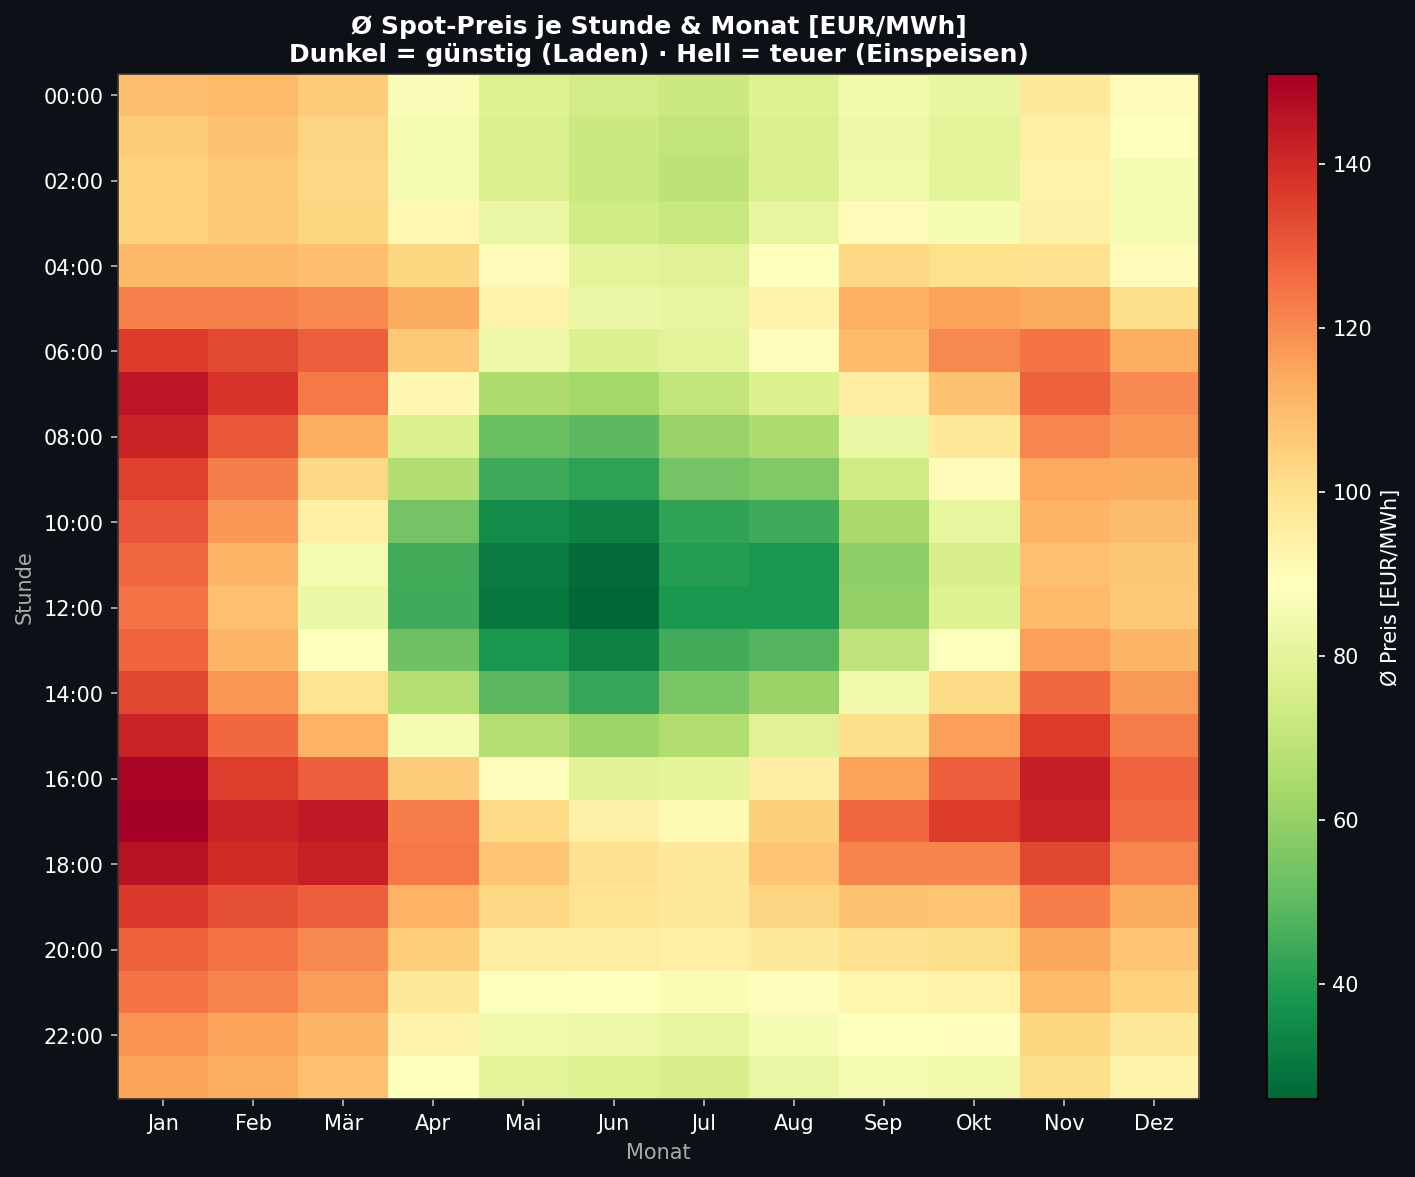


Marktstruktur: Ø Spot-Preis CH 2023–2024 — Stunde × Monat



In [2]:
show('chart2a_heatmap_preis.png',
     'Marktstruktur: Ø Spot-Preis CH 2023–2024 — Stunde × Monat', width=900)

### 1.2 Saisonaler Jahresverlauf

Die Animation zeigt wie sich Preisniveau, Netzlast und Arbitrage-Spread über 52 Kalenderwochen entwickeln. Deutlich erkennbar: der Frühling hat den höchsten Arbitrage-Spread — danach fällt er im Sommer ab, der dafür Negativpreis-Stunden als Ladezyklen ohne Kosten bietet.


In [3]:
show_anim('anim_C_spread.gif',
          'Animation C: Arbitrage-Spread, Negativpreise & Dispatch-Effizienz über 52 Wochen',
          width=900)


Animation C: Arbitrage-Spread, Negativpreise & Dispatch-Effizienz über 52 Wochen



---
## 2. Wertquellen: Erlösstacking

Eine Batterie verdient aus mehreren Quellen gleichzeitig. Die Kombination bestimmt die tatsächliche Wirtschaftlichkeit:

| Erlösquelle | Beschreibung | Wer kann teilnehmen |
|-------------|-------------|--------------------|
| **Grid-Arbitrage** | Laden günstig, Einspeisen teuer | Alle Segmente |
| **Netzentlastung** | Peak-Shaving zur Spitzenlastzeit | Gewerbe, Industrie, Utility |
| **FCR/aFRR** | Regelenergiemarkt Frequenzhaltung | Industrie, Utility (>1 MW) |
| **Eigenverbrauch** | EV, Wärmepumpe, Photovoltaik kombiniert | Privat, Gewerbe |
| **Negativpreise** | Strom gratis oder mit Gutschrift laden | Alle Segmente |

**Nur Grid-Arbitrage allein** reicht bei Privat/Gewerbe meist nicht für attraktiven ROI. Ab Industrie-Skala wird es interessant — und Utility ist mit direktem Marktzugang klar rentabel.


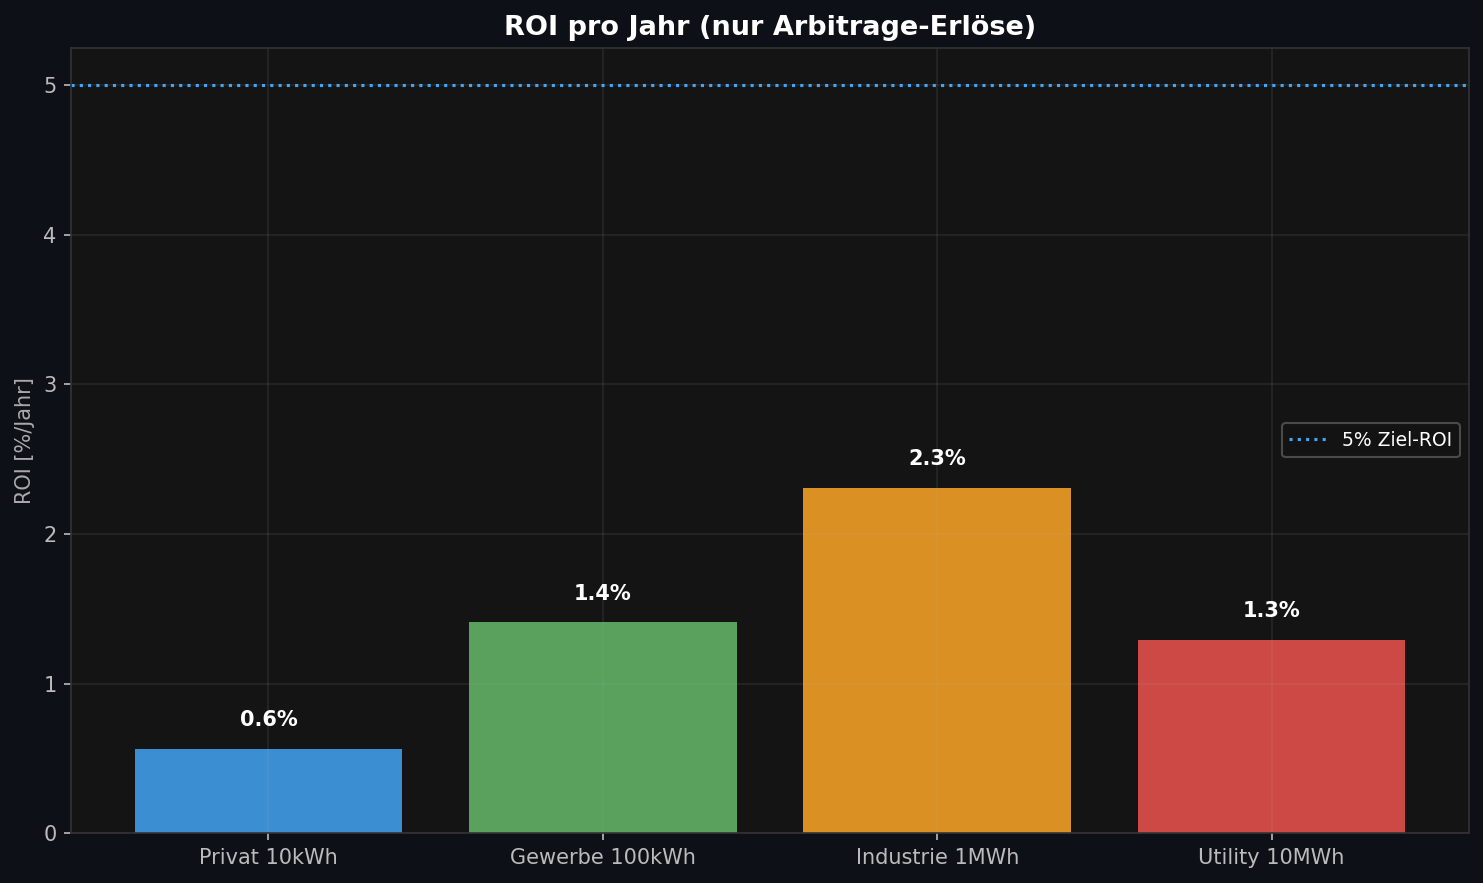


Basis-ROI aus reiner Arbitrage — vor Erlösstacking

Nicht vorhanden: output\charts\realistisch\nb15_roi_vergleich.png
Nicht vorhanden: output\charts\realistisch\nb15_breakeven_vergleich.png
Nicht vorhanden: output\charts\realistisch\nb15_nutzerverhalten_sensitivity.png


In [4]:
# ROI reine Arbitrage — Ausgangslage für Stacking-Überlegung
show('chart1b_roi.png',
     'Basis-ROI aus reiner Arbitrage — vor Erlösstacking', width=850)
# Vergleich alle Modelle inkl. Eigenverbrauch und Hybrid (NB15)
show('nb15_roi_vergleich.png',
     'ROI-Vergleich: Arbitrage / Eigenverbrauch / Hybrid statisch / Hybrid optimiert', width=950)
show('nb15_breakeven_vergleich.png',
     'Break-Even-Vergleich: Vier Modelle x Vier Segmente', width=950)
show('nb15_nutzerverhalten_sensitivity.png',
     'Robustheit Hybrid gegen Verbrauchsabweichung -- Privat 10 kWh', width=950)


---
## 3. Segmentstrategie: Wer profitiert wirklich?

### 3.1 Amortisation

Die Amortisationskurven zeigen wie lange das eingesetzte Kapital gebunden ist. Bei reiner Grid-Arbitrage (2023/2024) erreicht kein Segment den Break-Even innerhalb der modellierten Nutzungsdauer — das zeigt NB04 eindeutig. Erst mit Erlösstacking (FCR/aFRR, Eigenverbrauch, Peak-Shaving) wird Industrie/Utility rentabel; Privat/Gewerbe brauchen zusätzlich sinkende CAPEX und/oder einen höheren Marktspread.


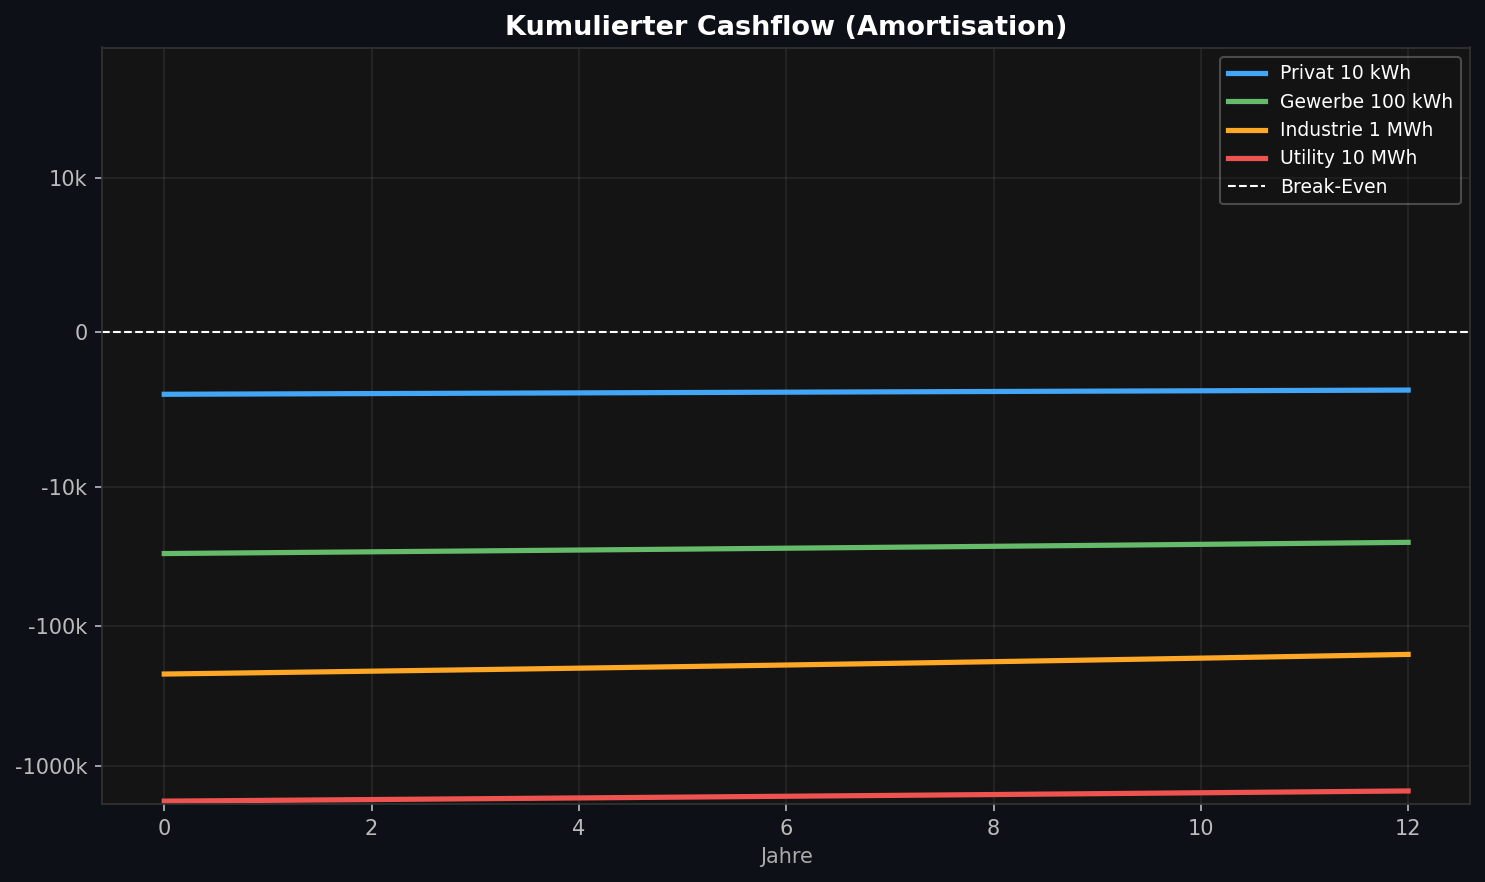


Kumulierter Cashflow 2023–2024 (nur Arbitrage)



In [5]:
show('chart1a_amortisation.png',
     'Kumulierter Cashflow 2023–2024 (nur Arbitrage)', width=900)

### 3.2 Segmentempfehlungen

| Segment | Strategie | Zusatzerlös nötig? | Empfehlung |
|---------|----------|-------------------|------------|
| **Privat 10 kWh** | Eigenverbrauchsopt. + Arbitrage + Peak-Shaving | Ja | EV/WP-Kombination; → [NB13](13_Eigenverbrauch.ipynb) |
| **Gewerbe 100 kWh** | Lastspitzenvermeidung + Arbitrage | Teilweise | Netzentgeltsenkung nutzen |
| **Industrie 1 MWh** | Arbitrage + FCR/aFRR | Nein (mit FCR) | Direkte Vermarktung |
| **Utility 10 MWh** | Vollmarktintegration, BVI-optimiert | Nein | Standort nach BVI wählen |


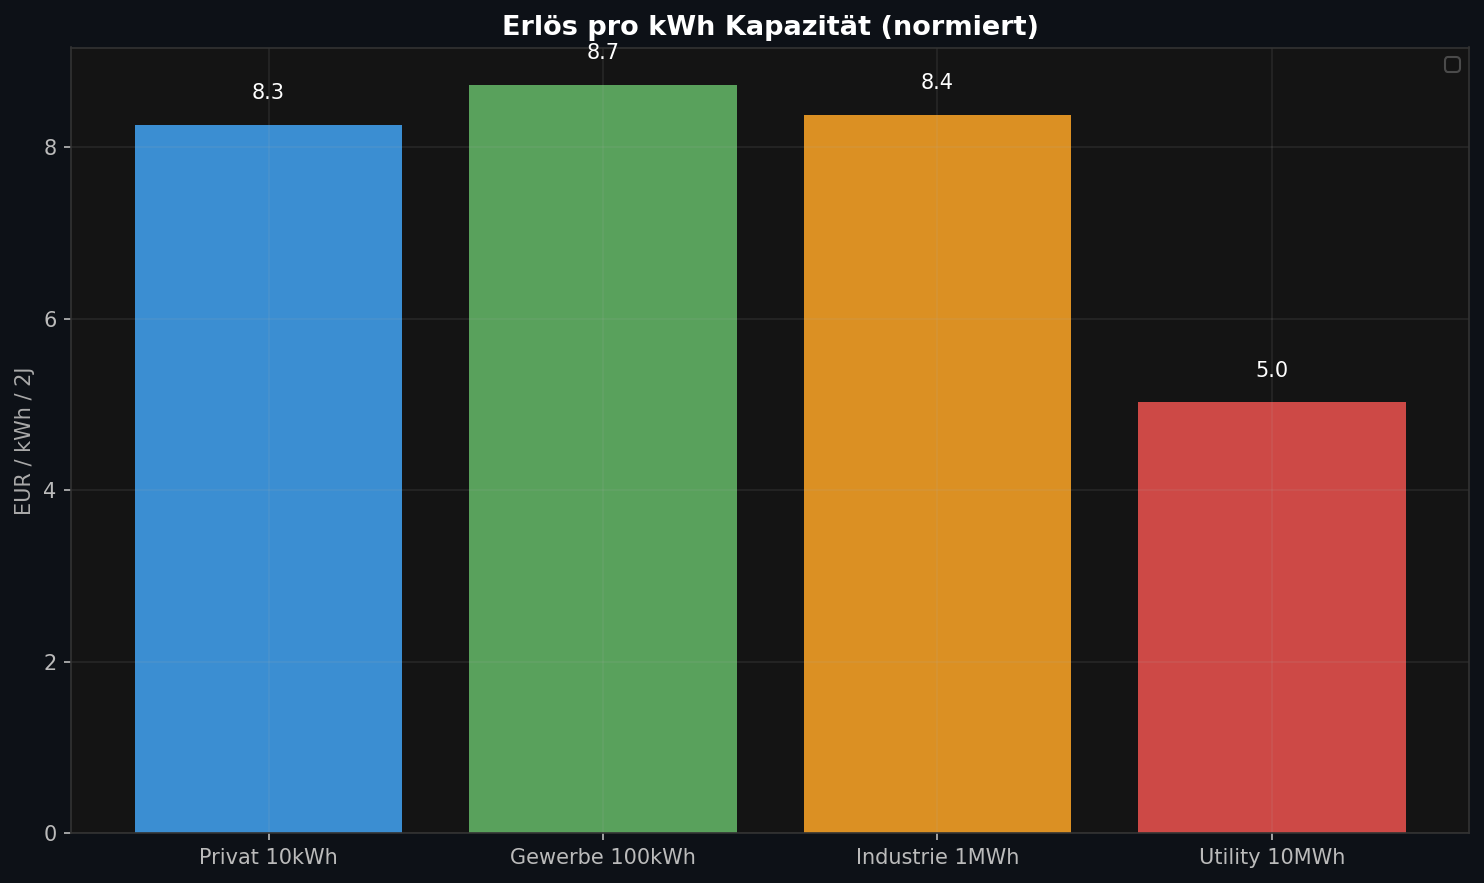


Erlös/kWh normiert — Effizienzvergleich



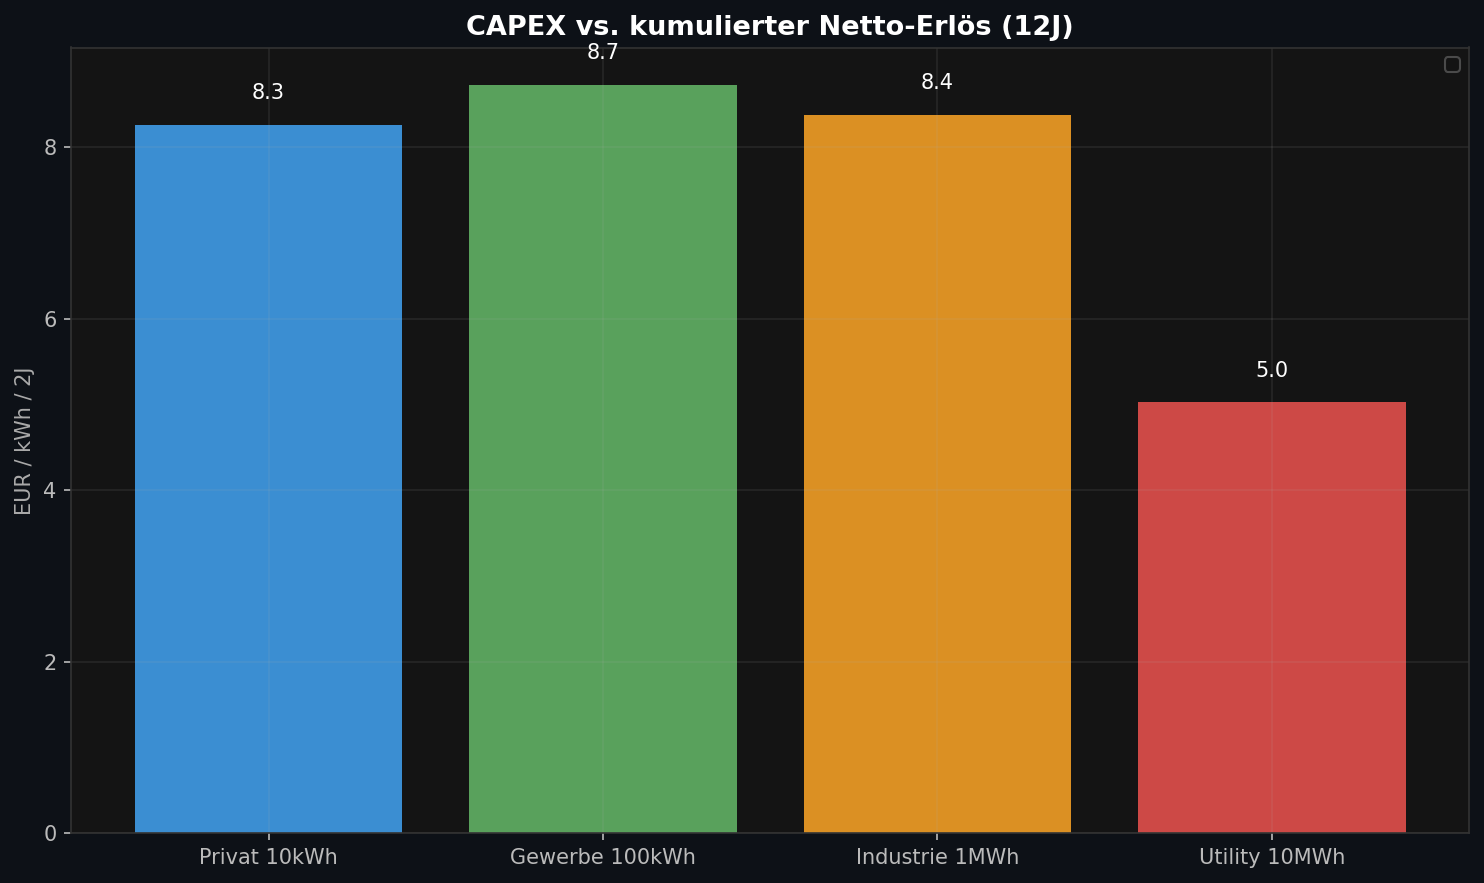


CAPEX vs. 12J-Netto-Erlös



In [6]:
show('chart1c_erloese_kwh.png', 'Erlös/kWh normiert — Effizienzvergleich', width=800)
show('chart1d_capex_ertrag.png', 'CAPEX vs. 12J-Netto-Erlös', width=800)

---
## 4. Timing-Strategie: Wann ist der Batterieeinsatz am wertvollsten?

### 4.1 Tageszeit

Die Abendstunden (17–20 Uhr) sind die rentabelsten Einspeisestunden. Die Morgenstunden (02–06 Uhr) und das Solarmittagsfenster (10–14 Uhr im Sommer) sind die optimalen Ladefenster. Ein saisonal adaptierter Dispatch-Algorithmus verschiebt das Ladefenster im Sommer von Nacht auf Mittag.


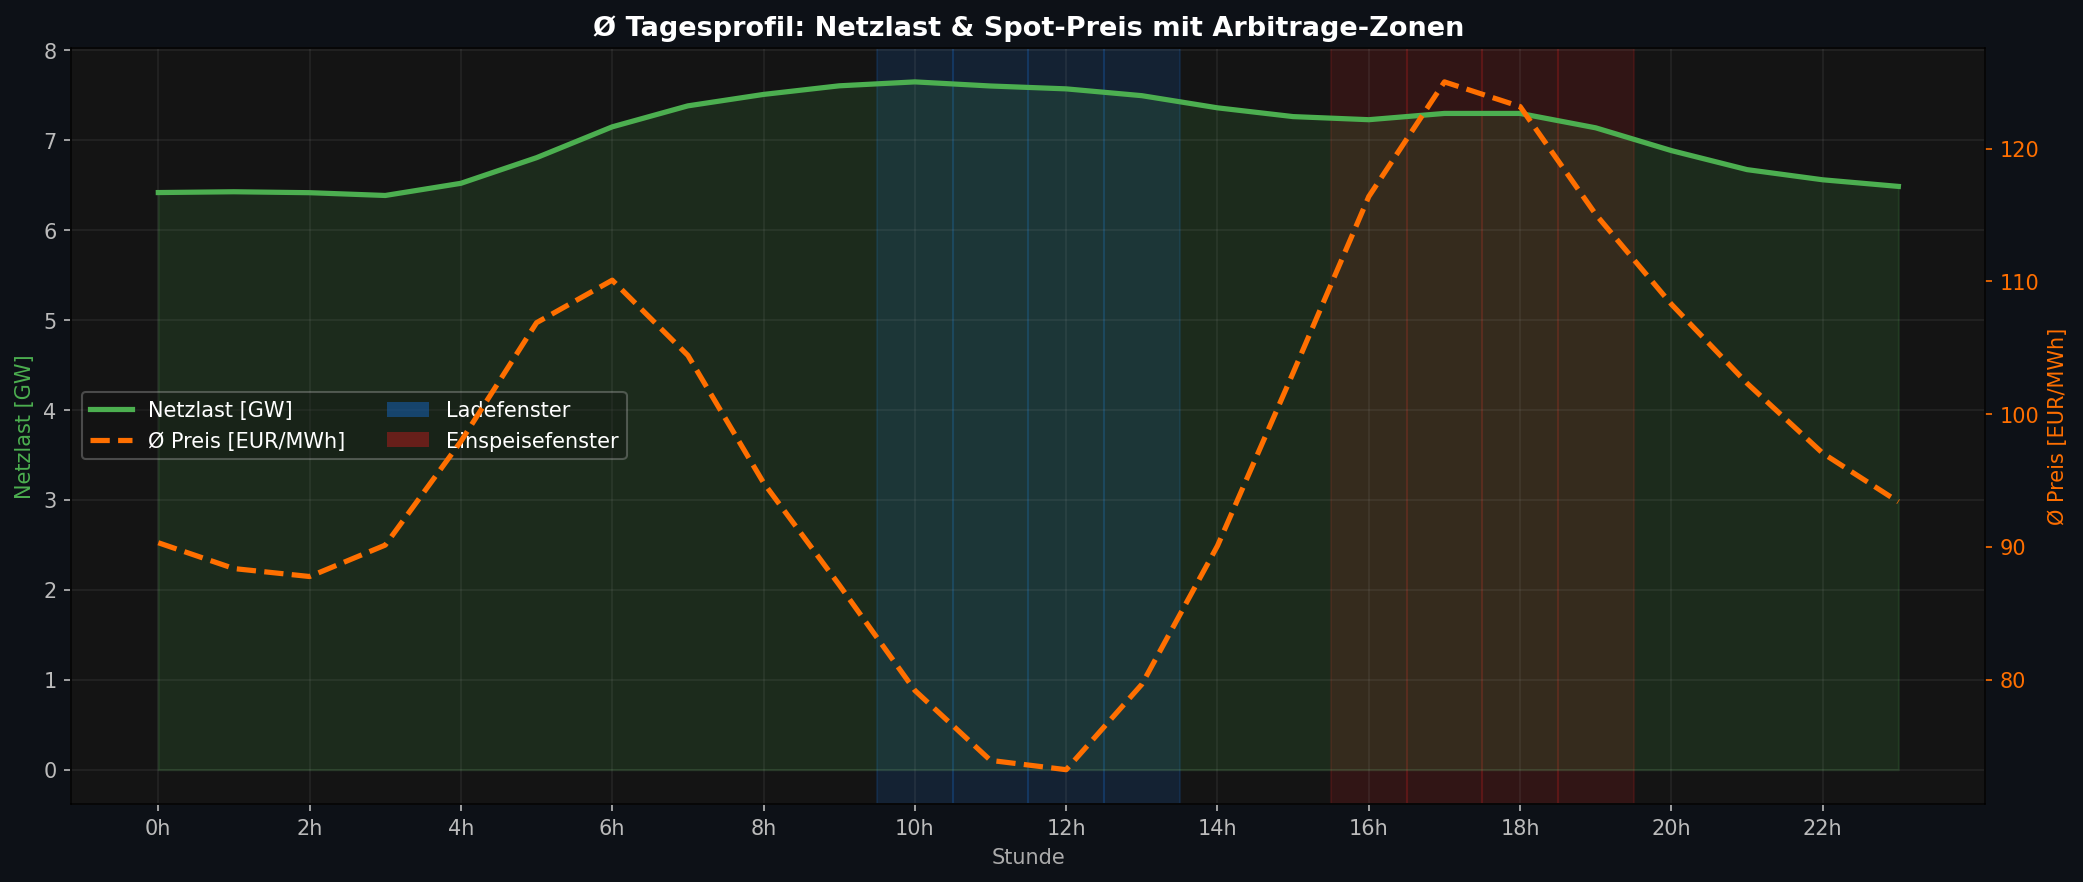


Ø Tagesprofil: Netzlast & Preis mit Lade/Einspeisefenstern



In [7]:
show('chart3_tagesprofil_single.png',
     'Ø Tagesprofil: Netzlast & Preis mit Lade/Einspeisefenstern', width=900)

### 4.2 Saisonale Dispatch-Optimierung

Alle vier Jahreszeiten bieten unterschiedliche Chancen — eine Beschränkung auf "Winter vs. Sommer" würde den wichtigsten Befund verfehlen:

| Saison | Spread | Optimales Ladefenster | Strategie |
|--------|--------|-----------------------|-----------|
| **Frühling** | **~139 EUR/MWh** (höchster) | Nacht + früher Morgen | Dispatch-Priorität: Frühling maximiert Erlös |
| **Herbst** | ~120 EUR/MWh | Nacht | Standard-Dispatch |
| **Sommer** | ~100 EUR/MWh | **Solar-Mittag** (Negativpreise!) | Ladefenster auf 10–14h verschieben |
| **Winter** | ~85 EUR/MWh (niedrigster) | Frühe Morgenstunden | Geringster Arbitrage-Erlös — entgegen Intuition |

Der Frühlingsabend (19:00) ist der rentabelste Einspeisezeitpunkt im Jahr — der Duck-Curve-Effekt ist maximal, weil Solar bereits aktiv ist aber Heizlast noch hoch. Im Sommer verschiebt sich das Ladefenster auf den Mittag — bei Negativpreisen sogar mit Vergütung.

**Ein saisonal adaptiver Dispatch-Algorithmus kann den Jahres-ROI um 10–20% steigern** gegenüber einem statischen Dispatch der immer dasselbe Zeitfenster verwendet.


Nicht vorhanden: output\charts\realistisch\chart5a_fruehling_single.png


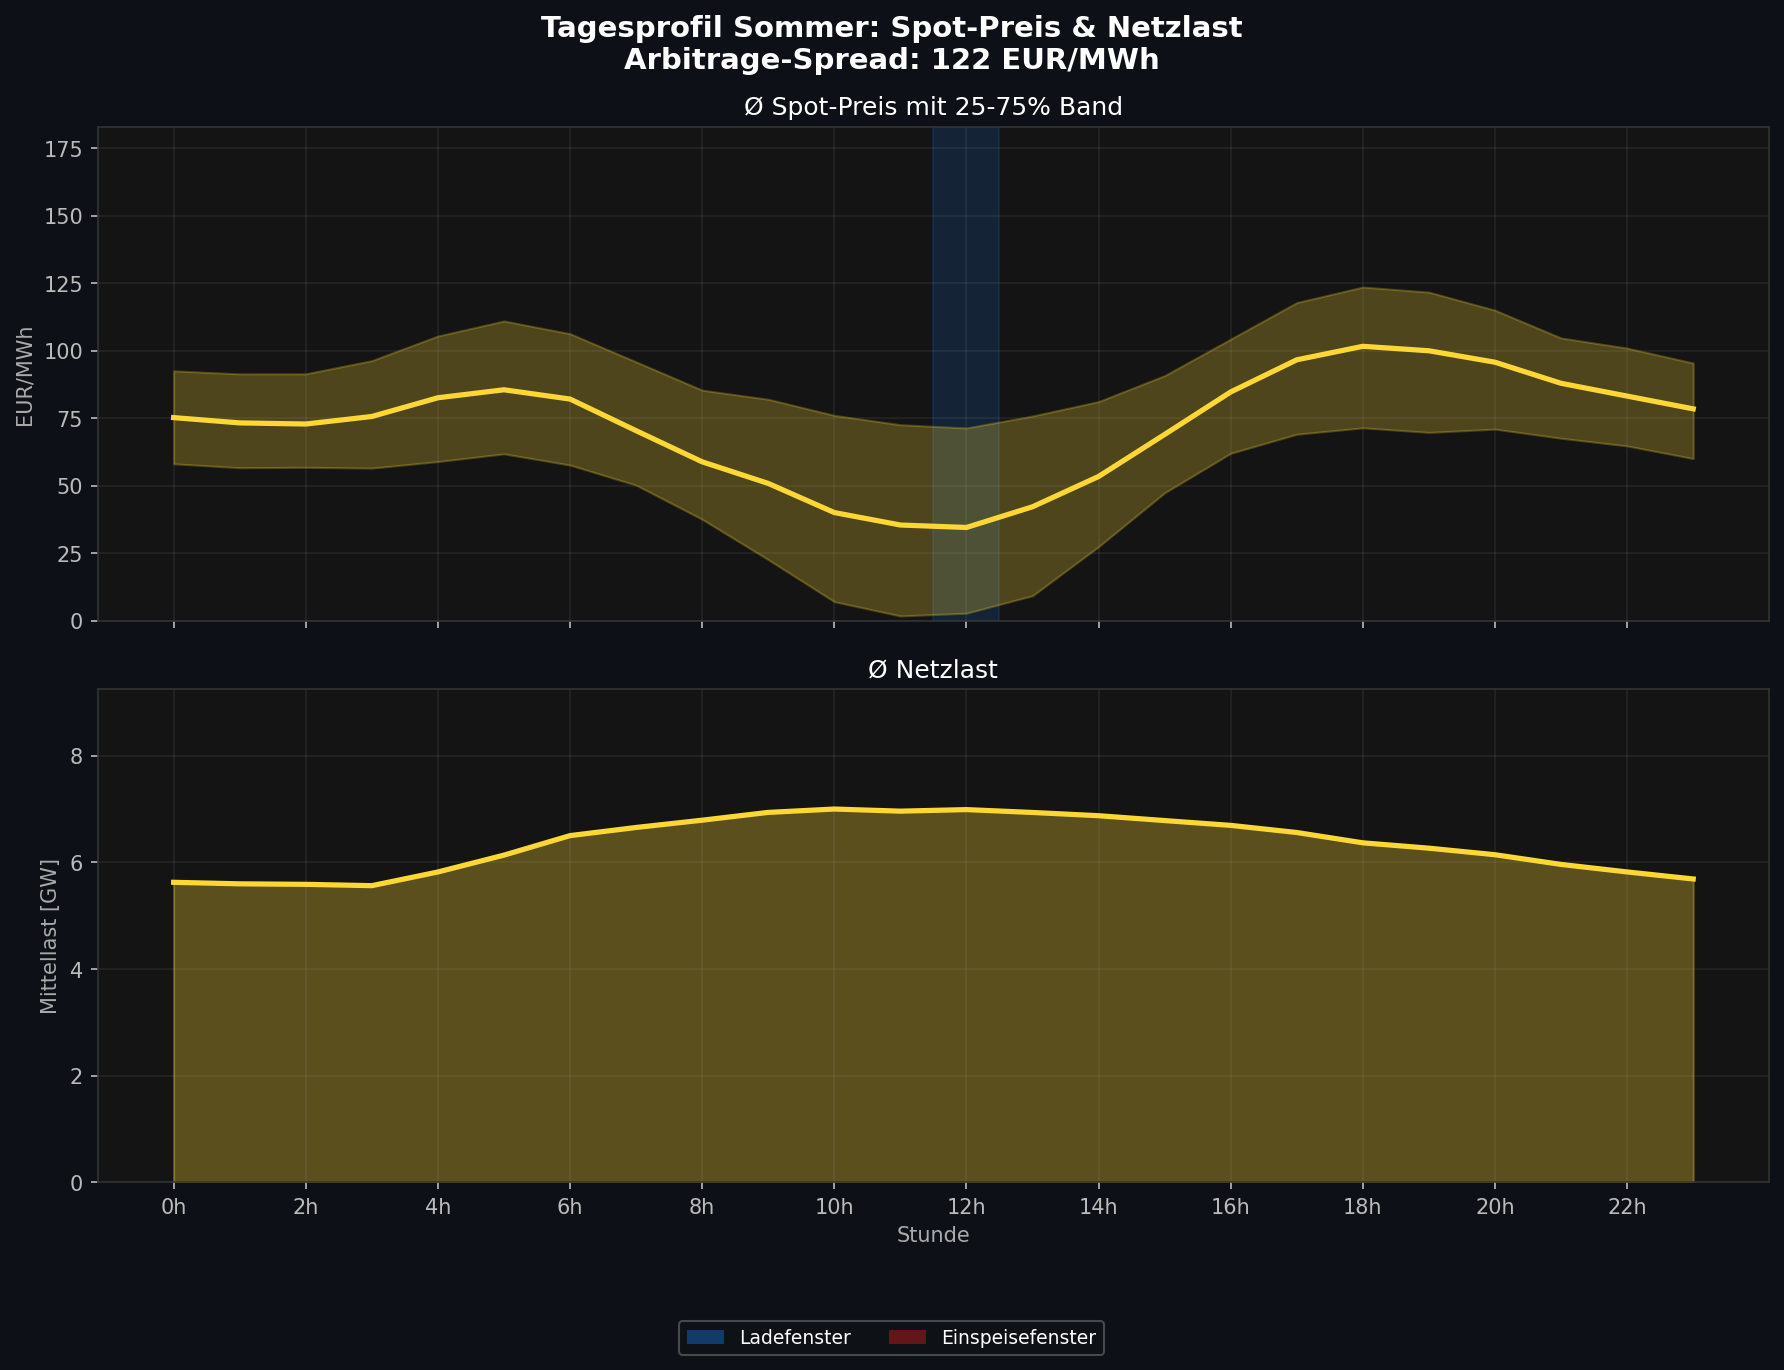


Sommer: Solar-Mittagstief, Negativpreise als Ladezyklen



In [8]:
show('chart5a_fruehling_single.png', 'Frühling: höchster Intraday-Spread (~139 EUR/MWh) — Duck-Curve-Effekt maximal', width=900)
show('chart5a_sommer_single.png', 'Sommer: Solar-Mittagstief, Negativpreise als Ladezyklen', width=900)


### 4.3 Jahresverlauf nach Tageszeit

Die vier Animationen zeigen wie sich die kritischen Tageszeiten über 52 Wochen verändern. Besonders aufschlussreich: 12:00 Uhr kippt von Winter (teuer) zu Sommer (günstig/negativ) — das Ladefenster wandert mit der Sonne.


In [9]:
# Morgenspitze
show_anim('anim_A_07h.gif',
          'Animation A — 07:00 Uhr: Morgenspitze über 52 Wochen', width=900)


Animation A — 07:00 Uhr: Morgenspitze über 52 Wochen



In [10]:
# Solarmittag
show_anim('anim_A_12h.gif',
          'Animation A — 12:00 Uhr: Solar-Mittagstief über 52 Wochen', width=900)


Animation A — 12:00 Uhr: Solar-Mittagstief über 52 Wochen



In [11]:
# Abendspitze
show_anim('anim_A_19h.gif',
          'Animation A — 19:00 Uhr: Abendspitze über 52 Wochen', width=900)


Animation A — 19:00 Uhr: Abendspitze über 52 Wochen



In [12]:
# Kombiniert alle 4
show_anim('anim_B_4panel.gif',
          'Animation B — Alle 4 Tageszeiten gleichzeitig: 00h / 07h / 12h / 19h', width=950)


Animation B — Alle 4 Tageszeiten gleichzeitig: 00h / 07h / 12h / 19h



---
## 5. Standortstrategie: Wo ist der Battery Value am höchsten?

### 5.1 Zonenimbalance

Die Schweiz ist keine homogene Stromzone. Fünf Netzregionen haben fundamental unterschiedliche Produktions-/Verbrauchsprofile:

- **Nord & West:** Ganzjährige Defizit-Zonen (ZH, TG, SG / VD, GE) — importieren konstant
- **Mitte:** AKW-Gürtel (AG, BE) — Grundlastüberschuss durch Kernkraft
- **Süd & Ost:** Wasserkraft-Exportzonen (VS, TI, GR) — saisonal stark variierend


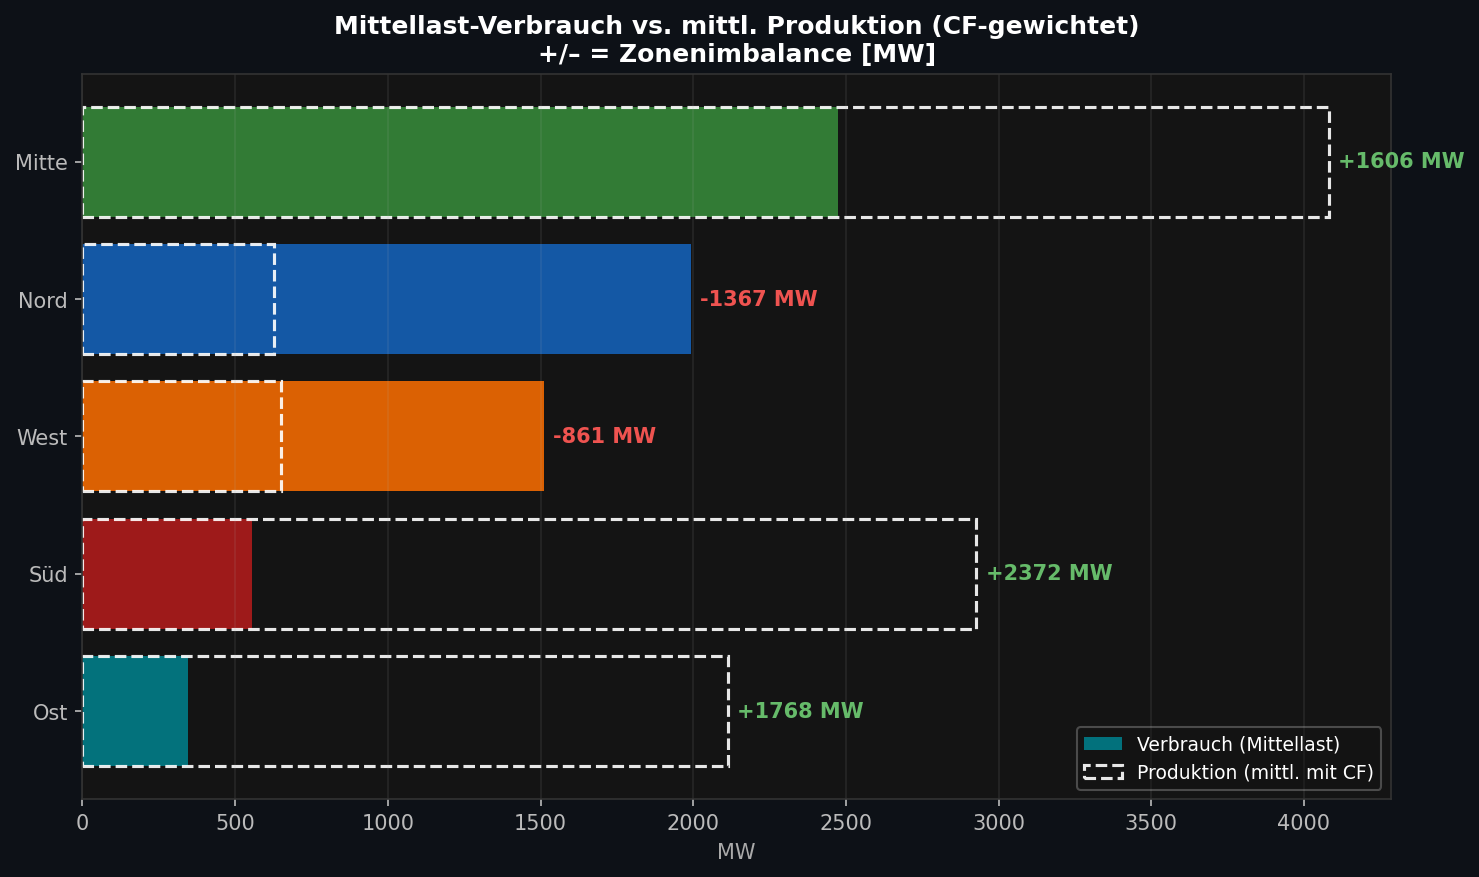


Zonenimbalance: Mittlere Produktion (CF-gewichtet) vs. Verbrauch [MW]



In [13]:
show_kuer('karte1_zonenimbalance_single.png',
     'Zonenimbalance: Mittlere Produktion (CF-gewichtet) vs. Verbrauch [MW]', width=900)

### 5.2 Battery Value Index (BVI)

Der BVI kombiniert Imbalance-Grösse und Engpassnähe zu einem standortspezifischen Wertindex. Er zeigt wo eine Batterie den grössten kombinierten wirtschaftlichen und systemischen Nutzen hat:

- **Süd** (BVI ~44%): Göschenen-Airolo-Engpass, grosse Wasserkraft-Überschüsse
- **Ost** (BVI ~25%): Alpenwasserkraft Graubünden, Nord-Süd-Exportachse
- **Mitte** (BVI ~20%): AKW-Standorte, Transit-Drehscheibe
- **West** (BVI ~7%): PST-Massnahmen Westgrenze
- **Nord** (BVI ~5%): Verbrauchsmaximum, importabhängig

**Achtung:** Hoher BVI ≠ hohe Arbitrage-Rendite. Süd/Ost haben hohen BVI aber geringeren Spread als Nord/West — der Gesamtwert muss beide Dimensionen einbeziehen.


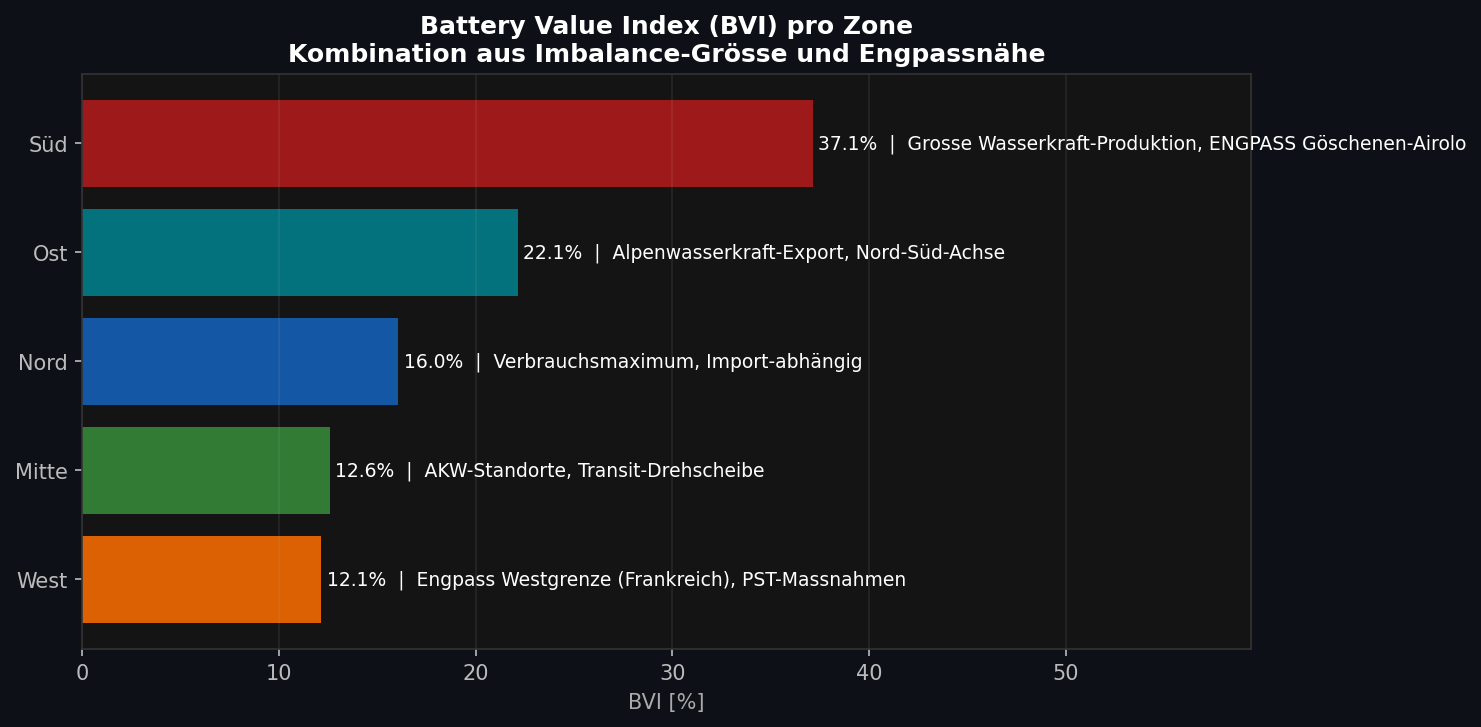


Battery Value Index (BVI) pro Zone — Jahresdurchschnitt



In [14]:
show_kuer('bvi_jahresdurchschnitt_single.png',
     'Battery Value Index (BVI) pro Zone — Jahresdurchschnitt', width=900)

### 5.3 Saisonale BVI-Verschiebung

Der BVI ist nicht statisch — er verschiebt sich mit den Jahreszeiten. Das verändert die optimale Standortempfehlung je nach Betriebsstrategie:


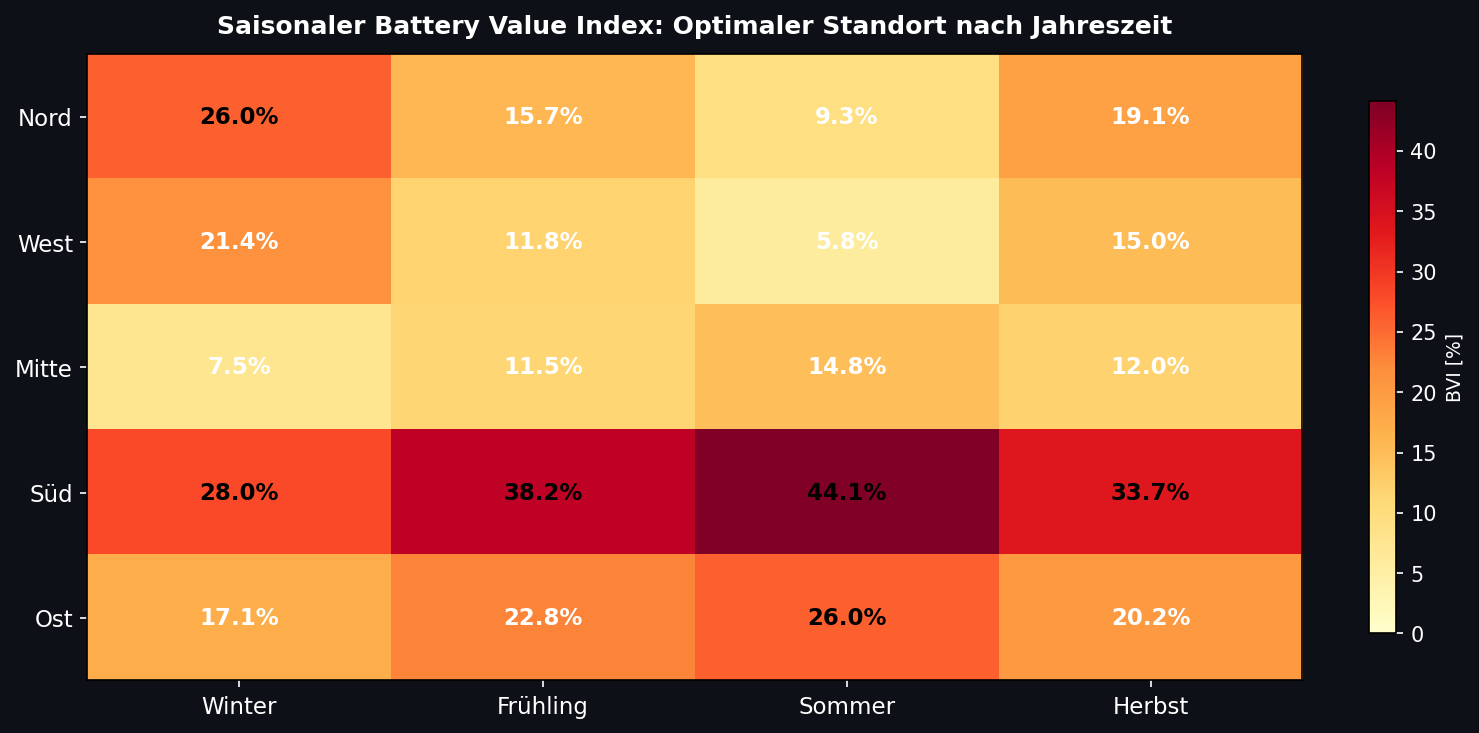


Saisonaler BVI: Optimaler Batteriestandort nach Jahreszeit



In [15]:
show_kuer('bvi_saisonal_heatmap_single.png',
     'Saisonaler BVI: Optimaler Batteriestandort nach Jahreszeit', width=900)

**Interpretation:**

| Saison | Beste Zone | Grund |
|--------|-----------|-------|
| Winter | Nord / West | Höchstes Netzdefizit; Intraday-Spread aber *niedriger* als Frühling |
| **Frühling** | **Süd / Ost** | **Höchster Arbitrage-Spread (~139 EUR/MWh) — Duck-Curve-Effekt maximal** |
| Sommer | Süd / Ost | Maximaler Überschuss, viel Pufferbedarf |
| Herbst | Mitte | Übergangsphase, AKW-Revision beendet |

**Für Investoren mit fixem Standort** empfehlen wir **Nord (ZH-Raum)**: stabiles Ganzjahres-Netzdefizit = ganzjährig relevanter Systemwert. Hinweis: höchster Intraday-Spread im Frühling (~139 EUR/MWh), nicht im Winter (~85 EUR/MWh) — Nord/West profitiert primär vom konstanten Defizit, nicht vom saisonalen Spread.


---
## 6. Skalierungsszenarien: Vom Einzelprojekt zum Virtual Power Plant

Wenn viele Batterien koordiniert dispatchen, entsteht ein aggregierter Netzentlastungseffekt der über die Einzelanlage hinausgeht. Die vier Szenarien zeigen das Systempotzenzial:


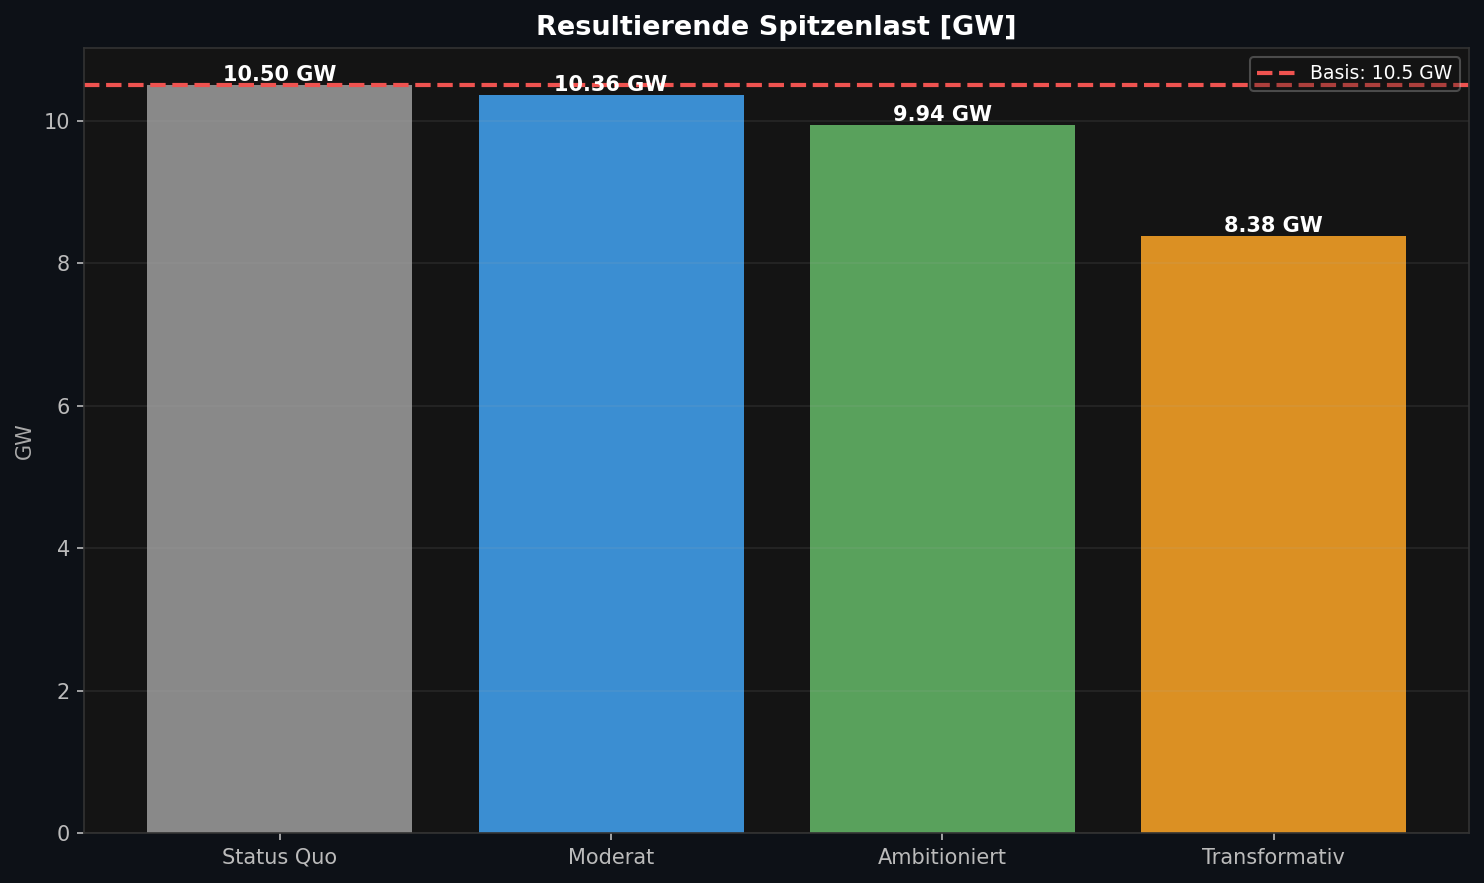


Systemwirkung: Spitzenlast je Rollout-Szenario



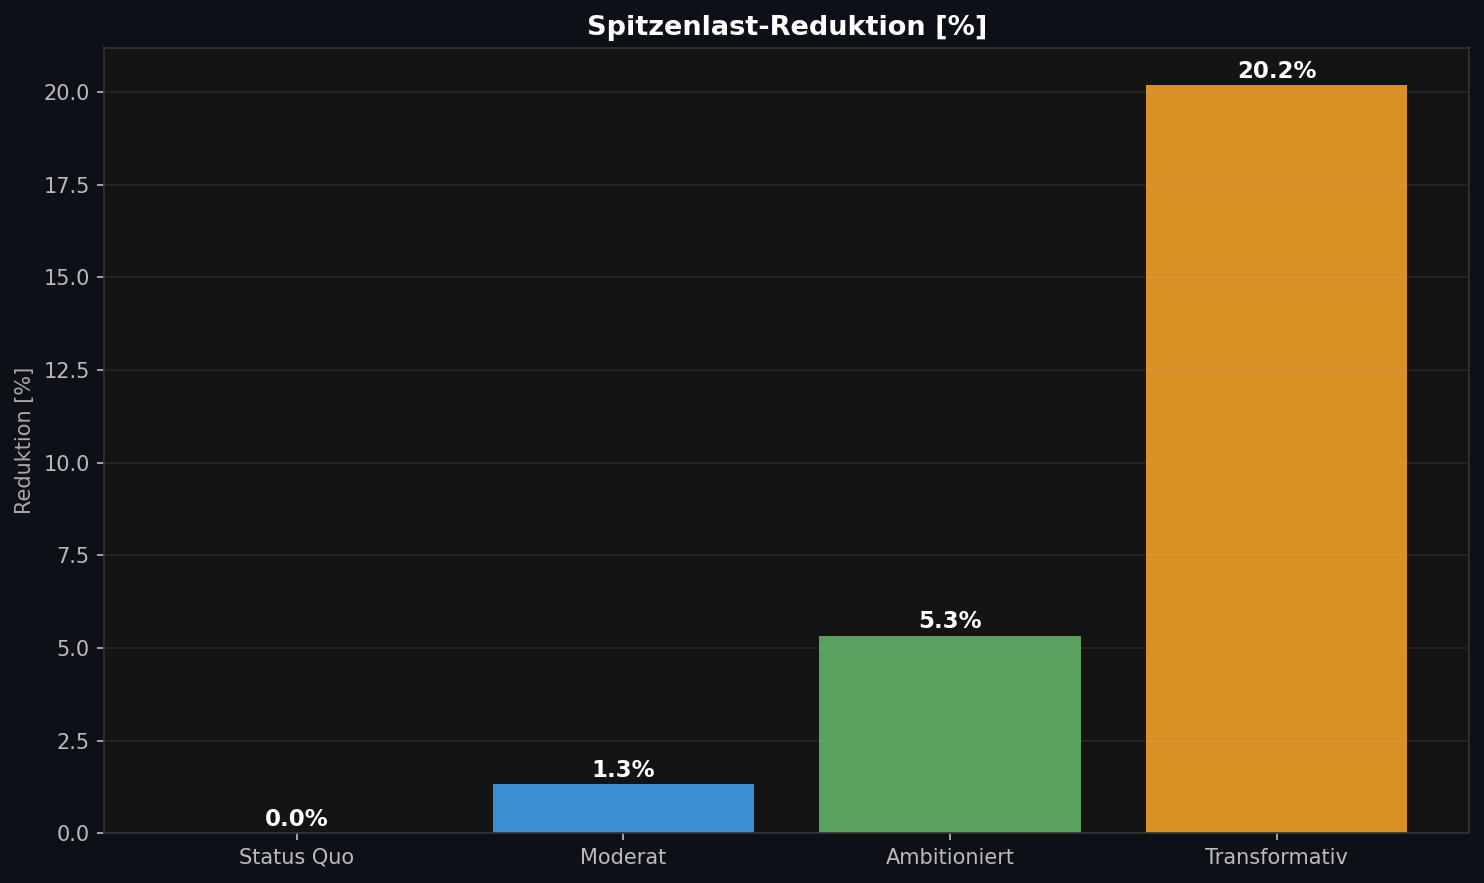


Spitzenlast-Reduktion [%] je Szenario



In [16]:
show('chart4a_spitzenlast.png', 'Systemwirkung: Spitzenlast je Rollout-Szenario', width=850)
show('chart4b_reduktion_pct.png', 'Spitzenlast-Reduktion [%] je Szenario', width=850)

In [17]:
if _gz_mode != 'unbekannt':
    print(f'Gleichzeitigkeit (aus NB2): {_gz_mode} ({_gz_rate})')
    other = 'optimistisch (70%)' if _gz_mode == 'realistisch' else 'realistisch (40%)'
    factor = 70/40 if _gz_mode == 'realistisch' else 40/70
    print(f'  Zum Vergleich: {other} ergibt {factor:.2f}× dieser Entlastungswerte.')
    print('  Schalter: NB2 → GLEICHZEITIGKEIT = ... → NB2 + NB3 neu ausführen')


Gleichzeitigkeit (aus NB2): realistisch (40%)
  Zum Vergleich: optimistisch (70%) ergibt 1.75× dieser Entlastungswerte.
  Schalter: NB2 → GLEICHZEITIGKEIT = ... → NB2 + NB3 neu ausführen


**Fazit Skalierung** (Zahlen: NB02 Sektion 5, Gleichzeitigkeit realistisch 40%):

| Szenario | Entlastung | Reduktion | Swissgrid-Relevanz |
|---|---|---|---|
| Status Quo (2024) | 0 MW | 0.0% | — |
| Moderat (2027) | 140 MW | 1.3% | Kaum messbar |
| **Ambitioniert (2030)** | **560 MW** | **5.3%** | Spürbar, aber noch nicht systemkritisch |
| Transformativ (2035) | 2 120 MW | 20.2% | Systemrelevant — koordinierter Dispatch nötig |

- Erst ab **Transformativ (800k Privat + 2k Industrie, 2035)** wird die Systemwirkung für Swissgrid wirklich relevant (20.2% Reduktion)
- Das Ambitioniert-Szenario (2030) liefert 5.3% — spürbar, aber noch nicht ausreichend für koordinierte Netzplanung
- BVI-gewichtete Verteilung erbringt gegenüber naiver Gleichverteilung +66% Mehrwert — d.h. Standort entscheidet massgeblich über Netzwirkung
- Die Sprünge von Moderat → Ambitioniert → Transformativ zeigen: ab einer kritischen Masse kippt der Systemeffekt in eine neue Grössenordnung


---
## 7. Virtual Power Plant (VPP) — Systemwirkung & Privat-Business-Case

> **Verbindung zu Sektion 6:** Die Skalierungsszenarien zeigen ab wann aggregierte
> Batterien systemrelevant werden. VPP ist der Koordinationsmechanismus der diese
> Skalierung erst ermöglicht — und gleichzeitig der Schlüssel zum Privat-Business-Case.

### 7.1 Das Grundproblem: Privat-Arbitrage allein reicht nicht

Die Dispatch-Simulation mit realen ENTSO-E-Preisdaten 2023/2024 zeigt:
Bei einem CAPEX von ~4'000 EUR (400 EUR/kWh × 10 kWh) und einem
Netto-Jahreserlös von <100 EUR aus reiner Arbitrage ergibt sich kein
wirtschaftlich tragbarer Business Case für Privathaushalte.

**Das bedeutet nicht, dass Batterien nie rentabel sind** — sondern dass
zwei Faktoren entscheidend sind: der Spread-Level und der CAPEX.

### 7.2 Spread-Entwicklung: Monitoring ist entscheidend


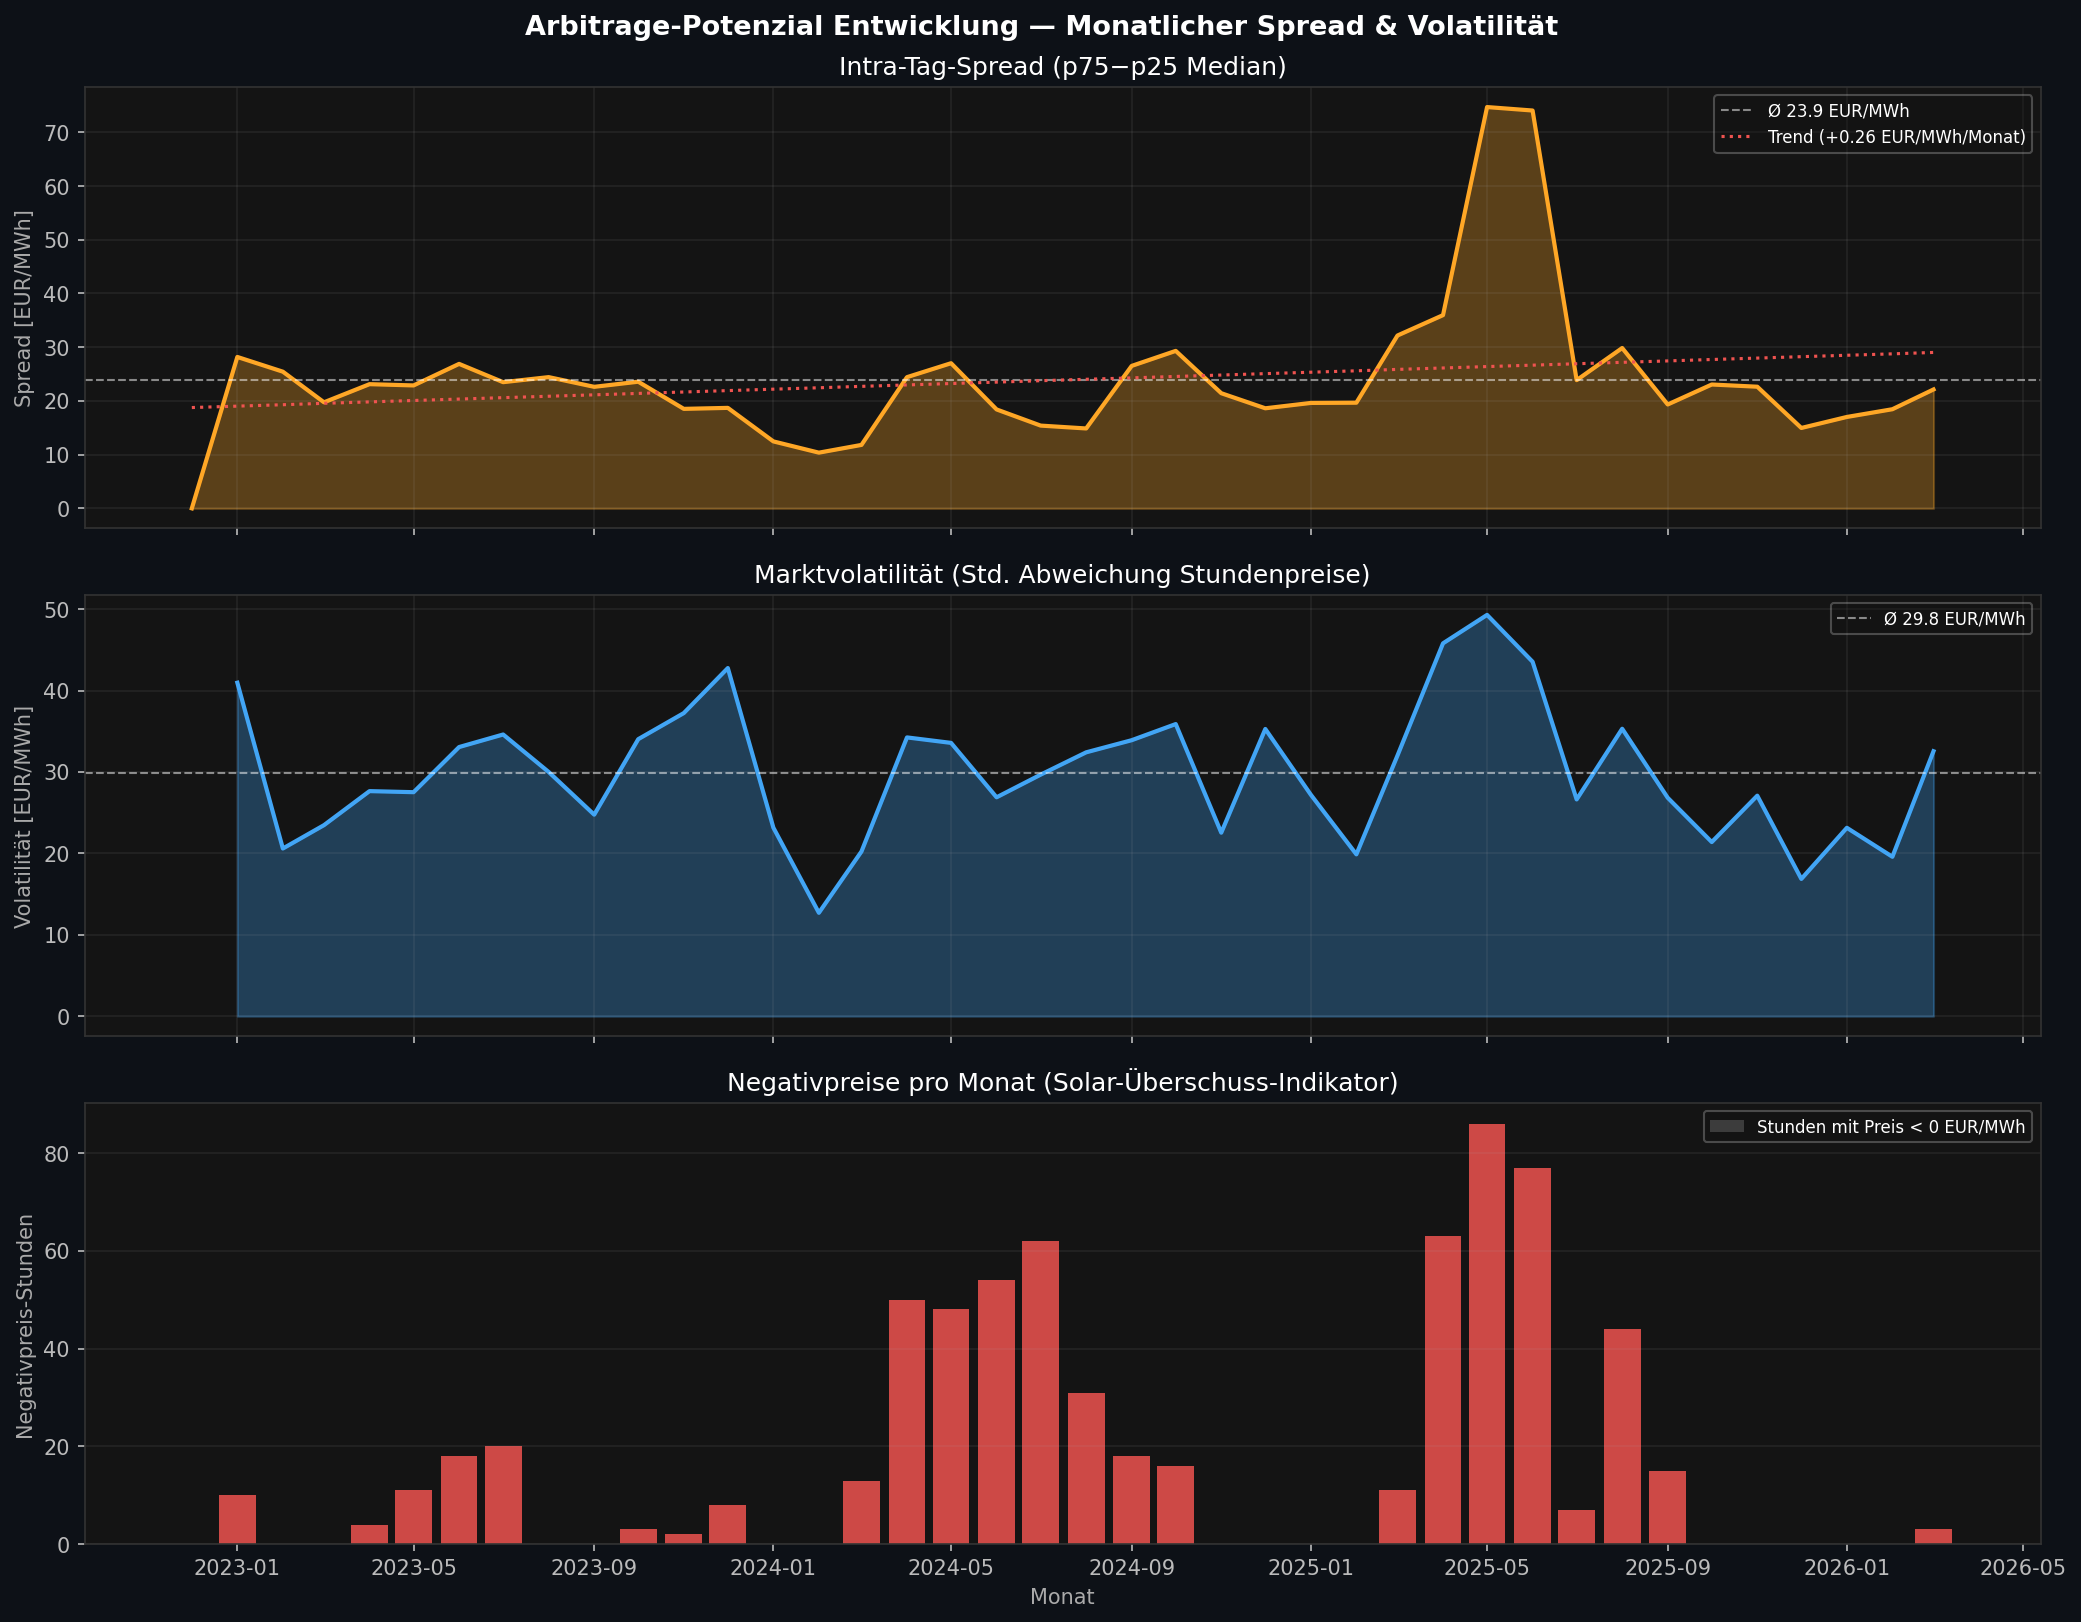


Spread-Entwicklung über Datenzeitraum — monatlicher Intra-Tag-Spread, Volatilität und Negativpreise. Trendlinie zeigt Richtung des Arbitrage-Potenzials.

Nicht vorhanden: output\charts\realistisch\nb15_revenue_split.png
Nicht vorhanden: output\charts\realistisch\nb15_capex_szenarien.png


In [18]:
# Chart 7: Spread-Zeitreihe als Marktindikator
if os.path.exists(os.path.join(KUER_DIR, 'chart7_spread_zeitreihe.png')):
    show_kuer('chart7_spread_zeitreihe.png',
         'Spread-Entwicklung über Datenzeitraum — monatlicher Intra-Tag-Spread, '
         'Volatilität und Negativpreise. Trendlinie zeigt Richtung des Arbitrage-Potenzials.',
         width=1050)
else:
    print('chart7_spread_zeitreihe.png nicht vorhanden → NB3 Chart 7 ausführen.')
# Erlösstacking und CAPEX-Szenarien (NB15)
show('nb15_revenue_split.png',
     'Erloesstacking: Wie setzt sich der Gesamterloes zusammen?', width=1000)
show('nb15_capex_szenarien.png',
     'CAPEX-Szenarien: ROI und Break-Even bei Heute / Trigger / Ziel', width=1050)


### 8.3 CAPEX-Lernkurve trifft steigenden Spread: Das Fenster öffnet sich

Zwei Trends wirken gleichzeitig in die richtige Richtung:

| Faktor | Historische Rate | Projektion |
|---|---|---|
| **CAPEX Li-Ion** | −10–15%/Jahr (2015–2024) | 2027: ~250 EUR/kWh, 2030: ~180 EUR/kWh |
| **Intra-Tag-Spread CH** | steigt mit EE-Ausbau | +5–15% jährlich (Schätzung) |

Die folgende Heatmap zeigt Break-Even-Jahre für alle CAPEX × Spread Kombinationen:


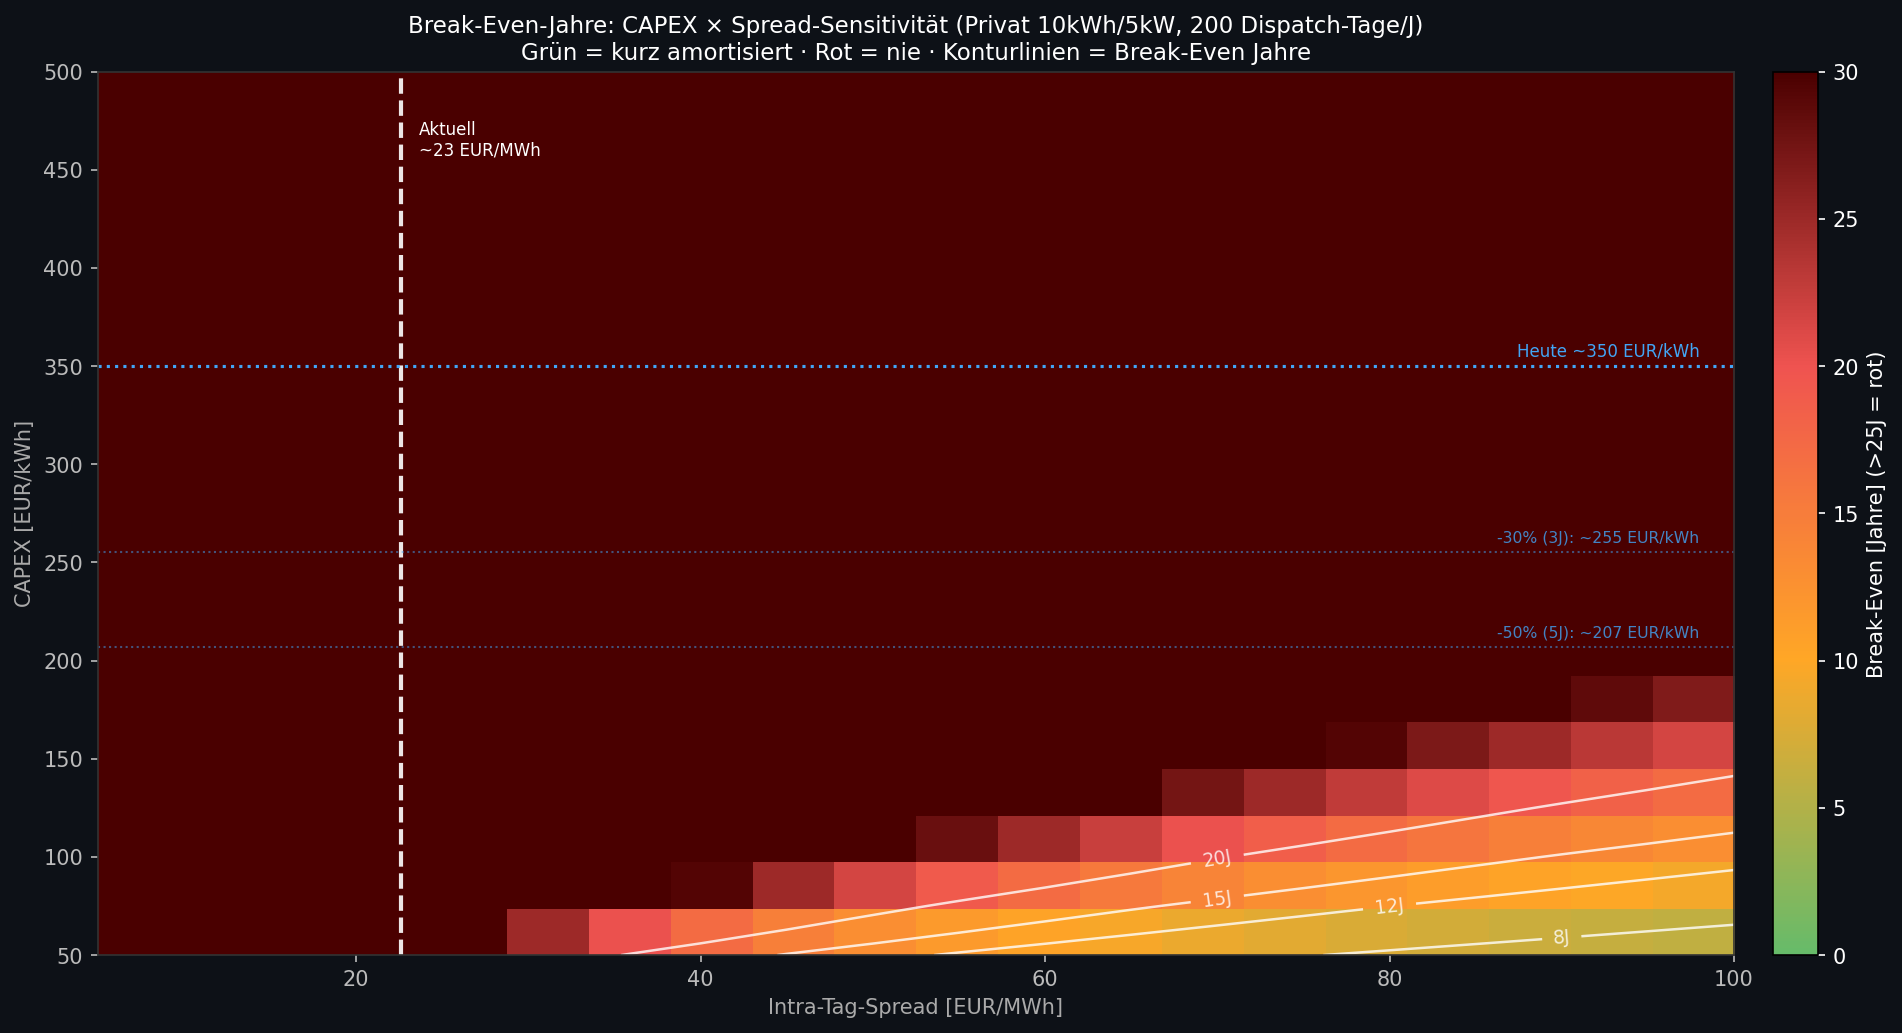


Break-Even-Jahre als Funktion von CAPEX und Intra-Tag-Spread (Privat 10kWh/5kW). Horizontale Linien: CAPEX-Lernkurve. Vertikale Linie: aktueller CH-Spread.

Nicht vorhanden: output\charts\realistisch\nb15_kombi_heatmap.png


In [19]:
# Chart 8: Sensitivitätsheatmap
if os.path.exists(os.path.join(KUER_DIR, 'chart8_sensitivitaet_heatmap.png')):
    show_kuer('chart8_sensitivitaet_heatmap.png',
         'Break-Even-Jahre als Funktion von CAPEX und Intra-Tag-Spread (Privat 10kWh/5kW). '
         'Horizontale Linien: CAPEX-Lernkurve. Vertikale Linie: aktueller CH-Spread.',
         width=1050)
else:
    print('chart8_sensitivitaet_heatmap.png nicht vorhanden → NB3 Chart 8 ausführen.')
# Kombinationsmatrix visuell aus echter Simulation (NB15)
show('nb15_kombi_heatmap.png',
     'Break-Even CAPEX x Spread -- Kombinationsmatrix', width=1000)


### 8.4 VPP als Erlös-Multiplikator

Auch bei aktuellem Spread verbessert VPP-Integration den Business Case:

| Erlösquelle | Mechanismus | Zusatzerlös |
|---|---|---|
| **Frequenzregelung (FCR)** | Automatische Netzstabilisierung | +30–80 EUR/kWh/Jahr |
| **Sekundärreserve (aFRR)** | Koordinierter Dispatch auf Signal | +20–50 EUR/kWh/Jahr |
| **Kapazitätszahlung** | Prämie für aggregierte Bereitschaft | +20–40 EUR/kWh/Jahr |
| **Smart Tariff** | Differenz-Netzentgelt bei Koordination | +15–30% auf Arbitrage |

### 8.5 Internationale Referenzmodelle

| Land | Modell | Status |
|---|---|---|
| **UK** | Octopus Powerloop, OVO Drive & Charge | Operativ |
| **DE** | Next Kraftwerke, Sonnen Community | Operativ |
| **AT** | Wien Energie Flex Pool | Pilotphase |
| **CH** | Swissgrid Flexibilitätsmarkt | In Aufbau (~2026–2028) |

### 8.6 Empfehlung: Jetzt beobachten, beim Trigger investieren

> **Der richtige Zeitpunkt für Privat-Investitionen:** Wenn CAPEX < 250 EUR/kWh
> **und** CH-Monatsmedian-Spread > 30 EUR/MWh **und** Swissgrid Flexibilitätsmarkt
> für aggregierte Heimspeicher geöffnet. Chart 7 (jährlich neu generieren) zeigt
> ob der Spread-Trigger erreicht ist. Chart 8 zeigt den Break-Even für den
> dann gültigen CAPEX.


---
## 8. Empirische Validierung

Der Business Case ist nicht nur theoretisch — er wird durch reale Grenzflussdaten bestätigt. CH importiert Strom genau in den Stunden mit dem höchsten Preis, und die Batterie-Dispatch-Logik greift in einem Grossteil dieser Import-Stunden. Grid-Arbitrage und Netzentlastung wirken damit **gleichzeitig** in die gleiche Richtung.


In [20]:
# ── Sektion 7: Import/Export-Validierung (Chart 6) ───────────────────────────
# Chart 6 wird in NB07 Cross-Border (Kür) erzeugt → output/kuer/<SZ_AKTIV>/
_c6 = 'chart6_import_export.png'
import os as _os
if _os.path.exists(_os.path.join(KUER_DIR, _c6)):
    show_kuer(_c6,
         'Import/Export-Validierung: CH kauft Strom genau wenn Batterien einspeisen sollten',
         width=900)
else:
    print('ℹ️  Chart 6 (Import/Export) nicht vorhanden.')
    print('   → NB07 Cross-Border ausführen um diese Analyse zu generieren.')


ℹ️  Chart 6 (Import/Export) nicht vorhanden.
   → NB07 Cross-Border ausführen um diese Analyse zu generieren.


---


---
## 9. Handlungsempfehlungen nach Stakeholder

### Für Investoren und Projektierer

1. **Standort zuerst:** Utility-Projekt in Süd/Ost für saisonale Arbitrage im Sommer,    in Nord für ganzjährig stabile Rendite
2. **Erlösstacking:** Grid-Arbitrage als Basiserlös, FCR/aFRR für Industrie/Utility    als primärer ROI-Treiber
3. **Saisonal optimierter Dispatch:** Ladefenster im Sommer auf Mittag verschieben,    Winter-Dispatch auf frühe Morgenstunden konzentrieren → +10–20% ROI
4. **Aggregation anstreben:** Ab 10+ Anlagen ist ein koordinierter Dispatch    (Virtual Power Plant) wirtschaftlich überzeugend

### Für Netzbetreiber und Swissgrid

1. **BVI-basierte Förderprogramme:** Batterien an Engpässen (Göschenen-Airolo,    AG-ZH Mittelland) mit Netzentgeltsenkungen incentivieren
2. **Saisonale Ausgleichsmechanismen:** Sommerpuffer in Süd/Ost explizit vergüten
3. **Digitale Plattform:** API für koordinierten Dispatch-Abruf statt Einzelverträge

### Für Politik und BFE

1. **Förderung dezentraler Speicher** über Netzentgeltsenkungen für nachweisbares Peak-Shaving
2. **Regulatorischer Rahmen** für Privat-Batterien als Systemdienstleister
3. **Datenzugang:** ENTSO-E Echtzeit-API und swissgrid-Engpassdaten für Marktakteure öffnen


---
## 10. Kombinationsmatrix: Parameter-Szenarien

Welche Parameterkombination ergibt welchen Business Case?

| Spread | CAPEX | Dispatch | Standort-BVI | Break-Even Privat | Empfehlung |
|--------|-------|----------|--------------|-------------------|------------|
| Heute (~20 EUR/MWh) | Heute (~350 EUR/kWh) | Reaktiv | Beliebig | > 25 J | ❌ Nicht investieren |
| Heute (~20 EUR/MWh) | Heute (~350 EUR/kWh) | DA-optimal | Hoch (Süd/Nord) | ~22 J | ❌ Abwarten |
| Heute (~20 EUR/MWh) | Trigger (250 EUR/kWh) | DA-optimal | Hoch | ~15 J | ⚠️ Grenzwertig |
| Trigger (30 EUR/MWh) | Heute (~350 EUR/kWh) | Reaktiv | Beliebig | ~20 J | ⚠️ Grenzwertig |
| Trigger (30 EUR/MWh) | Trigger (250 EUR/kWh) | DA-optimal | Mittel | ~10 J | ✅ Investieren |
| Trigger (30 EUR/MWh) | Trigger (250 EUR/kWh) | VPP-Stacking | Hoch | ~6–8 J | ✅✅ Ideal |
| Hoch (50 EUR/MWh) | Ziel (180 EUR/kWh) | VPP-Stacking | Hoch | ~4–5 J | ✅✅✅ Skalieren |

> **Lesehilfe:** Break-Even Privat (10 kWh / 400 EUR/kWh CAPEX heute). Werte skalierend —
> Industrie/Utility ist in jeder Zeile ca. 2–3× besser als Privat.

**Wann treten die Trigger ein?**
- Spread > 30 EUR/MWh: bei weiterem EE-Ausbau CH (~2026–2028 laut NB08 Trend)
- CAPEX < 250 EUR/kWh: laut NREL ATB Advanced-Szenario ~2025–2026 (NB11)
- VPP-Stacking: Swissgrid Flexibilitätsmarkt in Aufbau (~2026–2028)

> Vollständige Parametersensitivität → NB08 Chart 08-B (CAPEX × Spread Heatmap)  
> Technologieabhängigkeit → NB11 Eignungsmatrix  
> Erlösstacking-Details → NB09


---
## 11. Strategisches Fazit

Grid-Arbitrage mit Batteriespeichern ist in der Schweiz **wirtschaftlich machbar und systemisch wertvoll** — aber der Gesamtnutzen hängt stark von drei Variablen ab:

**Wer:** Industrie und Utility profitieren klar von reiner Arbitrage. Privat und Gewerbe brauchen Erlösstacking (Eigenverbrauch, Peak-Shaving, FCR/aFRR).

**Wann:** Frühling liefert den höchsten Intraday-Spread (~139 EUR/MWh) — entgegen intuitiver Erwartung. Der Duck-Curve-Effekt ist im Frühling am stärksten (Solar bereits aktiv, Heizlast noch hoch → grosser Tagesgangunterschied). Winter hat den niedrigsten Spread (~85 EUR/MWh). Sommer-Mittag bietet Negativpreis-Ladezyklen. Ein adaptiver Algorithmus verbessert den Jahres-ROI um 10–20% gegenüber statischem Dispatch.

**Wo:** Für maximale Systemwirkung: Engpasszonen Süd/Ost. Für robuste Ganzjahresrendite: Nord (ZH-Raum) als Defizit-Zone mit konstantem Netzdefizit — ganzjährig stabile Systemrelevanz. BVI-gewichteter Rollout bringt gegenüber naiver Verteilung +66% Netzentlastungseffekt.

---
*Erstellt im Rahmen des CAS Information Engineering – Scripting, ZHAW School of Engineering.*

> **Weiterführende Kür-Notebooks:**  
> [NB11 Technologievergleich](11_Technologievergleich.ipynb) · [NB12 Alternative Speicher](12_Alternative_Speicher.ipynb) · [NB13 Eigenverbrauchsopt.](13_Eigenverbrauch.ipynb) · [NB14 Produktsteckbrief](14_Produkt_Steckbrief.ipynb)  
*Daten: ENTSO-E (DL-DE-BY-2.0) · BFE (Open Government Data) · swisstopo swissBOUNDARIES3D · BFS STATPOP.*


---
| [← NB04 Business Case](04_Business_Case.ipynb) | [↑ Projektübersicht](00_Project_Overview.ipynb) | [→ NB06 Räumliche Analyse](06_Raeumliche_Analyse.ipynb) |
|:---|:---:|---:|
